/Users/jiasidan/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


1. 正在获取最新鲜的数据 (保留原始日期)...
2. 计算 50日均线 与 20日动量...
3. 执行华尔街级风控：2% 缓冲区 + 均线双重过滤...
4. 结算收益率与核心指标...

📊 最终版策略年化收益率: 42.21%
📈 最终版策略夏普比率:   3.90
📉 最终版策略最大回撤:   -2.98%
5. 绘制最终版对比图...


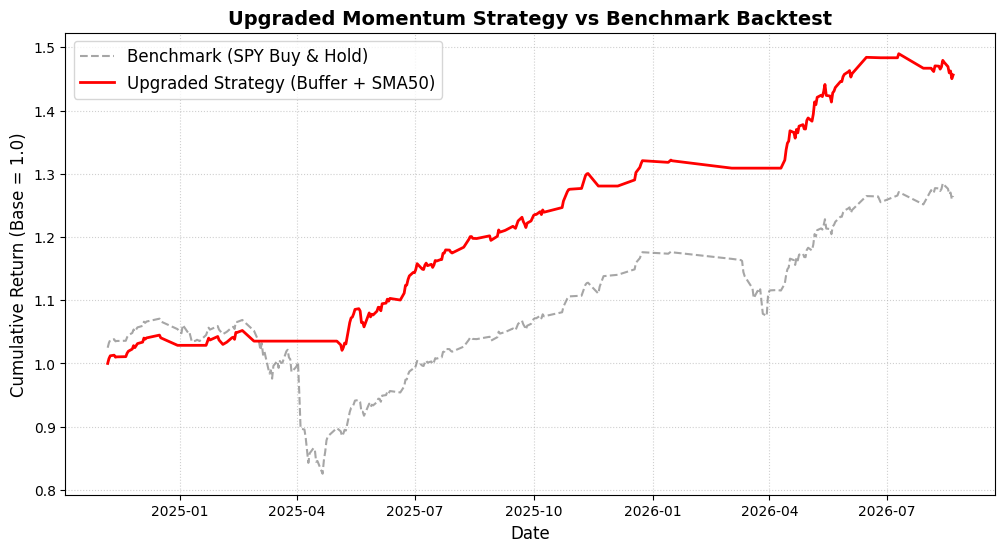

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("1. 正在获取最新鲜的数据 (保留原始日期)...")
data = yf.download("SPY", period="2y", interval="1d", progress=False)

if isinstance(data.columns, pd.MultiIndex):
    data.columns = [col[0] for col in data.columns]
data['Close'] = pd.to_numeric(data['Close'], errors='coerce')

print("2. 计算 50日均线 与 20日动量...")
data['MA50'] = data['Close'].rolling(window=50, min_periods=50).mean()
data['momentum_20'] = data['Close'] / data['Close'].shift(20) - 1

def mad_filter(series, n=3):
    median = series.median()
    mad = (series - median).abs().median()
    upper_bound = median + n * mad * 1.4826
    lower_bound = median - n * mad * 1.4826
    return series.clip(lower=lower_bound, upper=upper_bound)

data['momentum_20'] = mad_filter(data['momentum_20'])
# 核心：只删除空值，绝不使用 reset_index，完美保住日期！
data = data.dropna().copy() 

print("3. 执行华尔街级风控：2% 缓冲区 + 均线双重过滤...")
signal = pd.Series(np.nan, index=data.index)

# 真正的买入与卖出逻辑
buy_mask = (data['momentum_20'] > 0.02) & (data['Close'] > data['MA50'])
sell_mask = data['momentum_20'] < -0.02

signal[buy_mask] = 1
signal[sell_mask] = 0

# 缓冲区保持前一日状态，T+1 向后平移一天防止前视偏差
data['Signal'] = signal
data['Position'] = data['Signal'].ffill().shift(1).fillna(0)

print("4. 结算收益率与核心指标...")
data['Market_Return'] = data['Close'].pct_change()
data['Strategy_Return'] = data['Position'] * data['Market_Return']
data = data.dropna().copy()

data['Cumulative_Market'] = (1 + data['Market_Return']).cumprod()
data['Cumulative_Strategy'] = (1 + data['Strategy_Return']).cumprod()

total_days = len(data)
strategy_annual_return = (data['Cumulative_Strategy'].iloc[-1]) ** (252 / total_days) - 1
excess_return = data['Strategy_Return'] - ((1 + 0.02) ** (1/252) - 1)
sharpe_ratio = np.sqrt(252) * (excess_return.mean() / data['Strategy_Return'].std())
rolling_max = data['Cumulative_Strategy'].cummax()
max_drawdown = ((data['Cumulative_Strategy'] - rolling_max) / rolling_max).min()

print("\n" + "=" * 40)
print(f"📊 最终版策略年化收益率: {strategy_annual_return * 100:.2f}%")
print(f"📈 最终版策略夏普比率:   {sharpe_ratio:.2f}")
print(f"📉 最终版策略最大回撤:   {max_drawdown * 100:.2f}%")
print("=" * 40)

print("5. 绘制最终版对比图...")
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['Cumulative_Market'], label='Benchmark (SPY Buy & Hold)', color='gray', alpha=0.7, linestyle='--')
plt.plot(data.index, data['Cumulative_Strategy'], label='Upgraded Strategy (Buffer + SMA50)', color='red', linewidth=2)
plt.title('Upgraded Momentum Strategy vs Benchmark Backtest', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Return (Base = 1.0)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()